# Lab 03 — Geometric Transformations (AI-4002)
**Geometry changes WHERE a pixel is; photometry changes WHAT it looks like.**

| Section | What's inside |
|---|---|
| 0 | Setup + helper functions (build matrices by hand, apply with OpenCV) |
| A | Sir's notebook code: rotation, scale, shear, translation, rigid, perspective |
| B | Matrix theory demos: a,b,c,d effects, homogeneous coordinates, composition |
| C | Tasks 1–4: Scale (fingerprint) · Rotation (satellite) · Shear (barcode) · Translation (treasure map) |
| D | Tasks 5–7: Rigid (robot chip) · Similarity (blueprint) · General affine from 3 points (glitched image) |
| E | Tasks 8–10: Perspective (sidewalk) · Homography panorama (stadium) · Full hierarchy (master forger) |

Hierarchy: **Affine** = Linear (rotation, scale, shear; scale→similarity→rigid) + Translation · **Projective** (homography) → perspective.
`warpAffine` takes a **2×3** matrix, `warpPerspective` a **3×3**. dsize is always **(width, height)**.

## 0. Setup — sample images + helpers

In [1]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
from skimage import data
os.makedirs('data', exist_ok=True)
if not os.path.exists('data/image.jpg'):
    cv2.imwrite('data/image.jpg', cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR))

def show(images, titles, cols=None, size=4):
    cols = cols or len(images)
    rows = int(np.ceil(len(images) / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(size * cols, size * rows))
    ax = np.array(ax).ravel()
    for a in ax: a.axis('off')
    for a, im, t in zip(ax, images, titles):
        a.imshow(im if im.ndim == 2 else cv2.cvtColor(im, cv2.COLOR_BGR2RGB), cmap='gray' if im.ndim == 2 else None); a.set_title(t)
    plt.tight_layout(); plt.show()

# ---- 3x3 homogeneous building blocks (image coords: x right, y DOWN) ----
def T(tx, ty):  return np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], np.float64)
def S(sx, sy=None):
    sy = sx if sy is None else sy
    return np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1]], np.float64)
def R(deg):      # with y pointing down, +deg turns the picture CLOCKWISE on screen
    t = np.deg2rad(deg); c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], np.float64)
def SH(kx=0, ky=0): return np.array([[1, kx, 0], [ky, 1, 0], [0, 0, 1]], np.float64)

def warp(img, M3, size):           # size = (width, height)
    return cv2.warpAffine(img, M3[:2].astype(np.float32), size)
print('helpers ready')

helpers ready


## A. Sir's notebook code (copy-ready)

scaled shape: (1536, 1536, 3) | rotation matrix:
 [[   0.707    0.707 -106.039]
 [  -0.707    0.707  256.   ]]


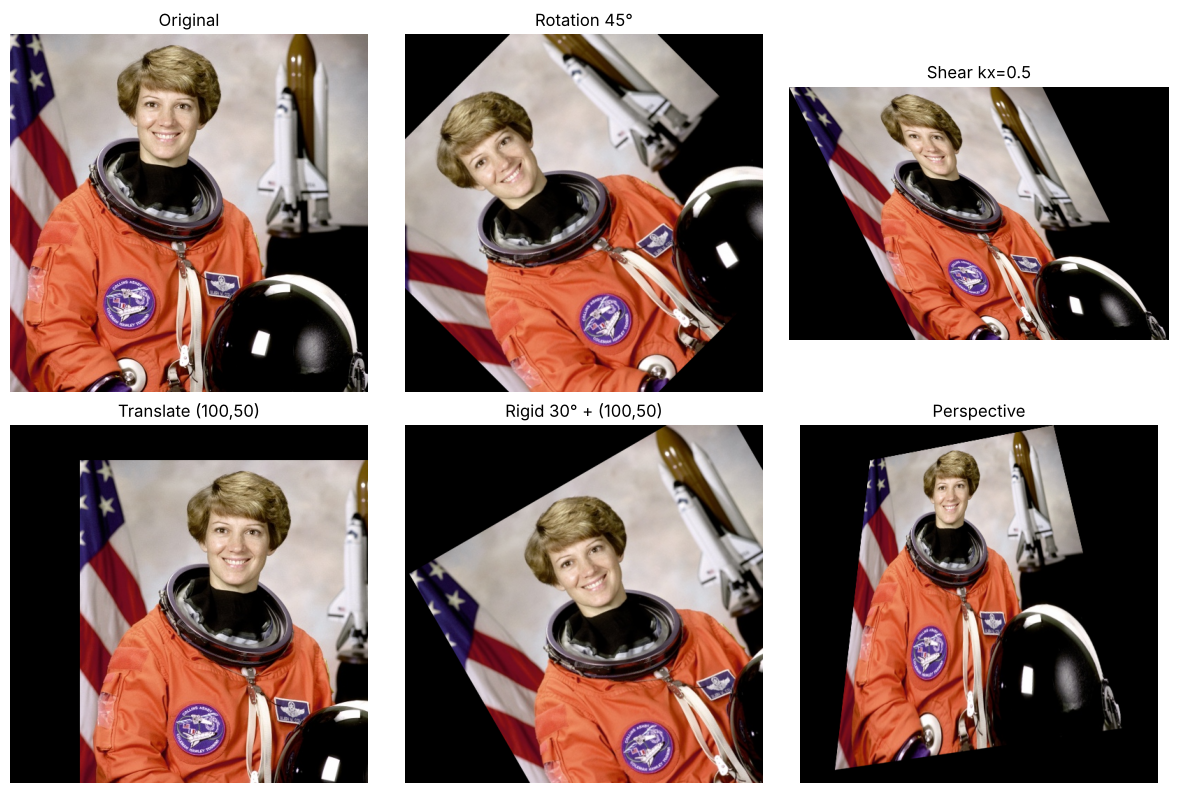

In [2]:
image = cv2.imread('data/image.jpg')
if image is None: raise FileNotFoundError('data/image.jpg')
height, width = image.shape[:2]
center = (width // 2, height // 2)

# Rotation (linear)
M_rot = cv2.getRotationMatrix2D(center, 45, 1.0)           # +45 = counter-clockwise, scale 1
rotated = cv2.warpAffine(image, M_rot, (width, height))

# Scale (linear)
scaled = cv2.resize(image, None, fx=3, fy=3, interpolation=cv2.INTER_LINEAR)

# Shear (linear) - widen canvas so nothing is cut
kx = 0.5
M_sh = np.float32([[1, kx, 0], [0, 1, 0]])
sheared = cv2.warpAffine(image, M_sh, (int(width + abs(kx) * height), height))

# Translation (affine)
tx, ty = 100, 50
M_tr = np.float32([[1, 0, tx], [0, 1, ty]])
translated = cv2.warpAffine(image, M_tr, (width, height))

# Rigid = rotation + translation, scale MUST be 1
M_rig = cv2.getRotationMatrix2D(center, 30, 1.0)
M_rig[0, 2] += 100; M_rig[1, 2] += 50
rigid = cv2.warpAffine(image, M_rig, (width, height))

# Perspective (projective) - 4 point pairs
src = np.float32([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]])
dst = np.float32([[100, 50], [width - 150, 0], [width - 50, height - 80], [50, height - 20]])
H = cv2.getPerspectiveTransform(src, dst)                     # 3x3
persp = cv2.warpPerspective(image, H, (width, height))

print('scaled shape:', scaled.shape, '| rotation matrix:\n', M_rot.round(3))
show([image, rotated, sheared, translated, rigid, persp],
     ['Original', 'Rotation 45°', 'Shear kx=0.5', 'Translate (100,50)', 'Rigid 30° + (100,50)', 'Perspective'], cols=3)

## B. Matrix theory demos
2×2 matrix **[[a, b], [c, d]]** — read as **columns**: (a, c) = where the X-axis lands, (b, d) = where the Y-axis lands.
* a = horizontal scale (negative ⇒ flip horizontally) · d = vertical scale (negative ⇒ flip vertically)
* b = horizontal shear (x' = x + b·y) · c = vertical shear (y' = c·x + y)
* x' = a·x + b·y,  y' = c·x + d·y. Linear maps keep the origin fixed: A·0 = 0 ⇒ **cannot translate**.

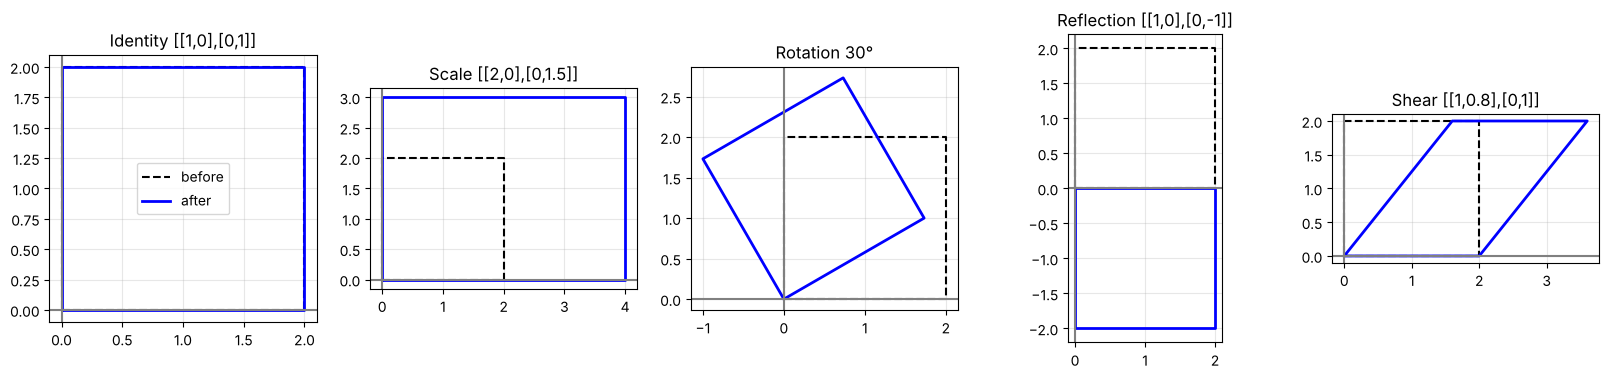

Origin after any 2x2 matrix: [0 0]


In [3]:
square = np.array([[0, 0], [2, 0], [2, 2], [0, 2], [0, 0]], float).T     # unit-ish square as columns
mats = {'Identity [[1,0],[0,1]]': [[1, 0], [0, 1]], 'Scale [[2,0],[0,1.5]]': [[2, 0], [0, 1.5]],
        'Rotation 30°': [[np.cos(np.pi/6), -np.sin(np.pi/6)], [np.sin(np.pi/6), np.cos(np.pi/6)]],
        'Reflection [[1,0],[0,-1]]': [[1, 0], [0, -1]], 'Shear [[1,0.8],[0,1]]': [[1, .8], [0, 1]]}
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for a, (name, A) in zip(ax, mats.items()):
    p = np.array(A) @ square
    a.plot(*square, 'k--', label='before'); a.plot(*p, 'b-', lw=2, label='after'); a.set_title(name)
    a.set_aspect('equal'); a.grid(alpha=.3); a.axhline(0, c='gray'); a.axvline(0, c='gray')
ax[0].legend(); plt.show()
print('Origin after any 2x2 matrix:', np.array([[3, 1], [2, 5]]) @ np.array([0, 0]))

In [4]:
# Homogeneous coordinates: (x, y) -> (x, y, 1) lets a 3x3 matrix TRANSLATE
p = np.array([10, 20, 1])
print('T(100,50) @ (10,20,1) =', T(100, 50) @ p)                  # -> (110, 70, 1)

# Composition: one master matrix. Order matters - rightmost is applied FIRST.
M = T(100, 50) @ R(30) @ S(2)          # scale, then rotate, then translate
print('master matrix:\n', M.round(3))
print('same as step by step:', np.allclose(M @ p, T(100, 50) @ (R(30) @ (S(2) @ p))))
print('order matters? T@S != S@T :', not np.allclose(T(10, 0) @ S(2), S(2) @ T(10, 0)))

# OpenCV sign note: getRotationMatrix2D(+θ) == our R(-θ) about the centre (counter-clockwise on screen)
c = (width / 2, height / 2)
mine = (T(*c) @ R(-45) @ T(-c[0], -c[1]))[:2]
print('matches cv2.getRotationMatrix2D:', np.allclose(mine, cv2.getRotationMatrix2D(c, 45, 1.0)))

T(100,50) @ (10,20,1) = [110.  70.   1.]
master matrix:
 [[  1.732  -1.    100.   ]
 [  1.      1.732  50.   ]
 [  0.      0.      1.   ]]
same as step by step: True
order matters? T@S != S@T : True
matches cv2.getRotationMatrix2D: True


# C. Tasks 1–4 (Linear + Translation)
## Task 1 — The Tiny Fingerprint (Linear: Scale 300%)
Build **S = [[3,0],[0,3]]** by hand. To keep it **centred**: choose translation t = c_new − S·c (c = old centre, c_new = canvas centre). On a 3× canvas t = 0; on a same-size canvas t = c − 3c = −2c (zoom-in on the centre).

S =
 [[3. 0.]
 [0. 3.]] 
 t (3x canvas) = [0. 0.]  | t (same canvas) = [-100. -100.]
centre maps to: [150. 150.] = canvas centre (150.0, 150.0)


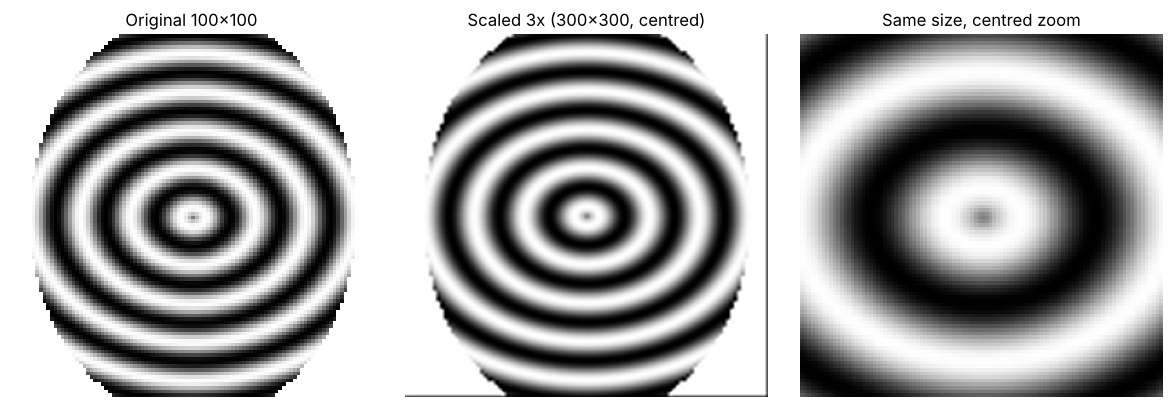

In [5]:
# create a small "fingerprint"
yy, xx = np.mgrid[0:100, 0:100]
finger = (127 + 127 * np.sin(np.hypot(xx - 50, (yy - 50) * 1.3) / 2.2)).astype(np.uint8)
finger[np.hypot(xx - 50, (yy - 50) * 0.8) > 45] = 255
h, w = finger.shape

A = np.array([[3, 0], [0, 3]], float)                 # manual 2x2 scaling matrix
c_old = np.array([w / 2, h / 2])

# (a) grow onto a 3x canvas, centred
new_w, new_h = 3 * w, 3 * h
t = np.array([new_w / 2, new_h / 2]) - A @ c_old     # = (0, 0)
M_big = np.hstack([A, t[:, None]]).astype(np.float32)
big = cv2.warpAffine(finger, M_big, (new_w, new_h), flags=cv2.INTER_CUBIC)

# (b) same screen size, zoom stays centred
t2 = c_old - A @ c_old                                 # = -2c
M_zoom = np.hstack([A, t2[:, None]]).astype(np.float32)
zoom = cv2.warpAffine(finger, M_zoom, (w, h), flags=cv2.INTER_CUBIC)

print('S =\n', A, '\n t (3x canvas) =', t, ' | t (same canvas) =', t2)
print('centre maps to:', A @ c_old + t, '= canvas centre', (new_w / 2, new_h / 2))
show([finger, big, zoom], ['Original 100x100', 'Scaled 3x (300x300, centred)', 'Same size, centred zoom'])

## Task 2 — The Dizzy Satellite (Linear: Rotation 45°)
R = [[cos θ, −sin θ], [sin θ, cos θ]]. **New canvas so corners are not chopped:**
W' = |w·cos θ| + |h·sin θ|,  H' = |w·sin θ| + |h·cos θ|, then shift: t = c_new − R·c_old.

tilted size 725x725 -> canvas needed 1026x1026


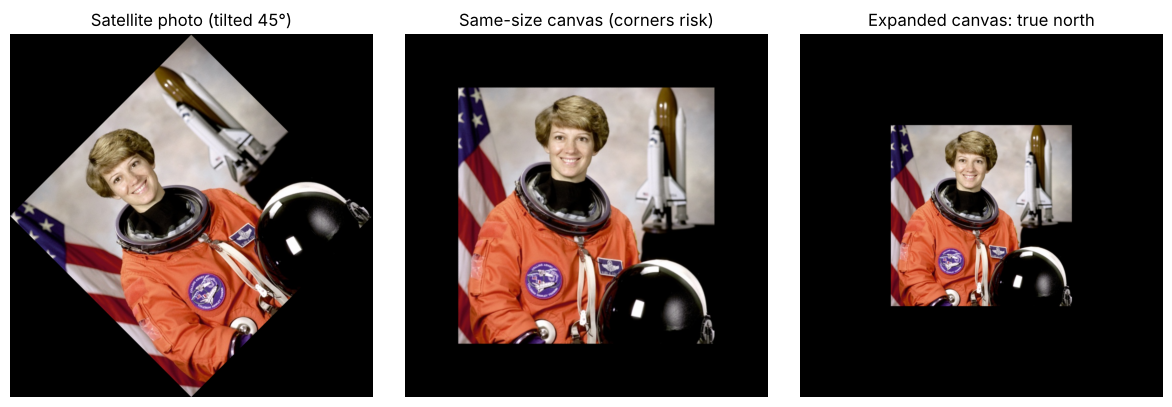

In [6]:
def rotate_expand(img, deg):
    th = np.deg2rad(deg); c, s = np.cos(th), np.sin(th)
    Rm = np.array([[c, -s], [s, c]])                       # manual 2x2 rotation
    h, w = img.shape[:2]
    new_w = int(np.ceil(abs(w * c) + abs(h * s)))           # bounding box of rotated image
    new_h = int(np.ceil(abs(w * s) + abs(h * c)))
    t = np.array([new_w / 2, new_h / 2]) - Rm @ np.array([w / 2, h / 2])
    M = np.hstack([Rm, t[:, None]]).astype(np.float32)
    return cv2.warpAffine(img, M, (new_w, new_h)), (new_w, new_h)

city = cv2.imread('data/image.jpg')
tilted, _ = rotate_expand(city, -45)                       # the "dizzy" photo (45° tilt)
fixed, dims = rotate_expand(tilted, 45)                    # spin back to true north
h0, w0 = tilted.shape[:2]
print(f'tilted size {w0}x{h0} -> canvas needed {dims[0]}x{dims[1]}')
naive = cv2.warpAffine(tilted, cv2.getRotationMatrix2D((w0/2, h0/2), -45, 1), (w0, h0))
show([tilted, naive, fixed], ['Satellite photo (tilted 45°)', 'Same-size canvas (corners risk)', 'Expanded canvas: true north'])

## Task 3 — The Fast Train Barcode (Linear: Shear)
Slant to the right means x' = x + k·y. Undo with the opposite shear **[[1, −k], [0, 1]]** (x' = x − k·y).

shear matrix:
 [[ 1.  -0.4]
 [ 0.   1. ]] 
restored == original: 1.0


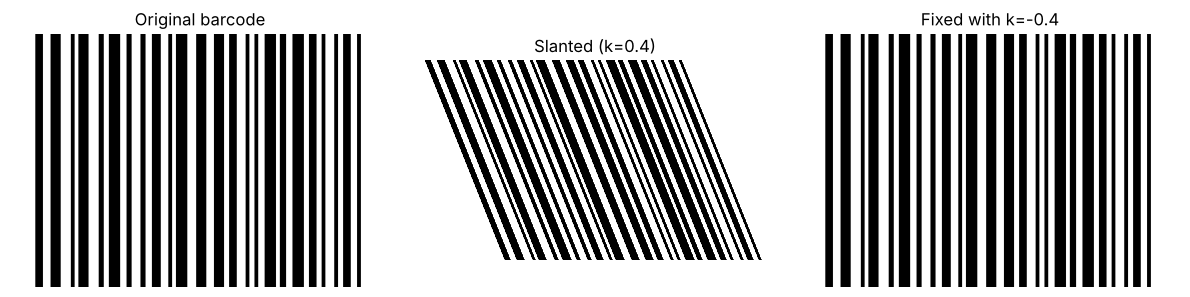

In [7]:
bars = np.full((200, 300), 255, np.uint8)
rng = np.random.default_rng(1); x = 20
while x < 280:
    bw = int(rng.integers(3, 10)); bars[:, x:x + bw] = 0; x += bw + int(rng.integers(3, 9))
k = 0.4
slanted = cv2.warpAffine(bars, np.float32([[1, k, 0], [0, 1, 0]]), (int(300 + k * 200), 200), flags=cv2.INTER_NEAREST, borderValue=255)

Sh_fix = np.array([[1, -k], [0, 1]], float)                 # manual 2x2 shear matrix
M_fix = np.hstack([Sh_fix, [[0], [0]]]).astype(np.float32)
straight = cv2.warpAffine(slanted, M_fix, (300, 200), flags=cv2.INTER_NEAREST, borderValue=255)
print('shear matrix:\n', Sh_fix, '\nrestored == original:', np.mean(straight == bars).round(3))
show([bars, slanted, straight], ['Original barcode', f'Slanted (k={k})', 'Fixed with k=-0.4'])

## Task 4 — The Hidden Treasure Map (Affine: Translation, 3×3)
X is 150 px to the **left** and 80 px **up** (off screen) ⇒ slide everything **right 150, down 80**: tx = +150, ty = +80.

T_fix =
 [[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]
X on screen before fix: [-50. -20.] -> after: [100.  60.]


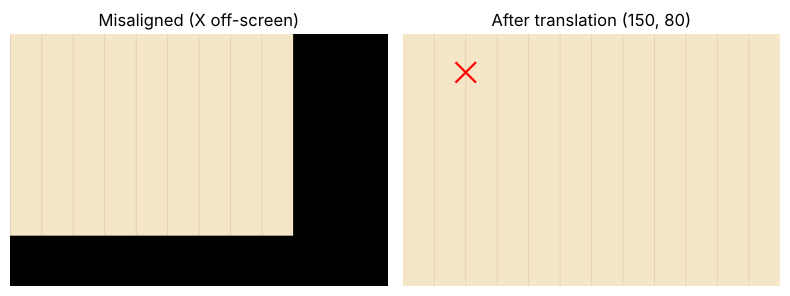

In [8]:
world = np.full((400, 600, 3), (200, 230, 245), np.uint8)        # the full map
for i in range(0, 600, 50): cv2.line(world, (i, 0), (i, 400), (180, 200, 220), 1)
X = (100, 60)                                                     # treasure location in the map
cv2.line(world, (X[0]-15, X[1]-15), (X[0]+15, X[1]+15), (0, 0, 255), 4); cv2.line(world, (X[0]+15, X[1]-15), (X[0]-15, X[1]+15), (0, 0, 255), 4)

T_bad = T(-150, -80)                     # how the display got misaligned
misaligned = warp(world, T_bad, (600, 400))
T_fix = T(150, 80)                       # 3x3 translation matrix
print('T_fix =\n', T_fix)
print('X on screen before fix:', (T_bad @ [*X, 1])[:2], '-> after:', (T_fix @ T_bad @ [*X, 1])[:2])
fixed_map = warp(world, T_fix @ T_bad, (600, 400))               # composed matrix applied to the map
show([misaligned, fixed_map], ['Misaligned (X off-screen)', 'After translation (150, 80)'])

# D. Tasks 5–7 (Rigid, Similarity, General Affine)
Recipe for "about a point": **T(target) · R(θ) · T(−pivot)** — move pivot to origin, rotate/scale, move to target. One 3×3 matrix.
## Task 5 — Robot Assembly Line (Rigid: Rotation + Translation, scale = 1)

Rigid 3x3:
 [[ 3.42000e-01  9.40000e-01  2.35070e+01]
 [-9.40000e-01  3.42000e-01  4.75667e+02]
 [ 0.00000e+00  0.00000e+00  1.00000e+00]] 
 det of rotation part = 1.0 (=1 -> shape preserved)


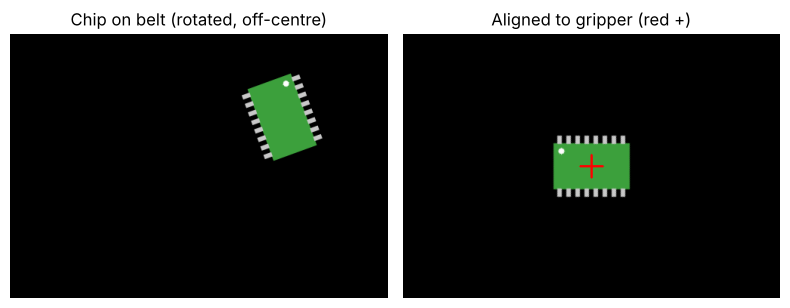

In [9]:
W, H = 500, 350
grip = np.array([250, 175])                                      # gripper centre
aligned = np.zeros((H, W, 3), np.uint8)
cv2.rectangle(aligned, (200, 145), (300, 205), (60, 160, 60), -1)      # chip body
for x in range(205, 300, 12): cv2.rectangle(aligned, (x, 135), (x + 5, 145), (200, 200, 200), -1); cv2.rectangle(aligned, (x, 205), (x + 5, 215), (200, 200, 200), -1)
cv2.circle(aligned, (210, 155), 4, (255, 255, 255), -1)           # pin-1 dot shows orientation

chip_c, theta = np.array([360, 110]), 70                          # chip is sideways & off-centre
M_bad = T(*chip_c) @ R(theta) @ T(*-grip)
on_belt = warp(aligned, M_bad, (W, H))

M_rigid = T(*grip) @ R(-theta) @ T(*-chip_c)                      # ONE 3x3: translate-rotate-translate
print('Rigid 3x3:\n', M_rigid.round(3), '\n det of rotation part =', np.linalg.det(M_rigid[:2, :2]).round(3), '(=1 -> shape preserved)')
fixed_chip = warp(on_belt, M_rigid, (W, H))
guide = fixed_chip.copy(); cv2.drawMarker(guide, tuple(grip), (0, 0, 255), cv2.MARKER_CROSS, 30, 2)
show([on_belt, guide], ['Chip on belt (rotated, off-centre)', 'Aligned to gripper (red +)'])

## Task 6 — The Architect's Blueprint (Similarity: Scale + Rotation + Translation)

Similarity 3x3:
 [[   3.072    2.151 -131.482]
 [  -2.151    3.072  260.136]
 [   0.       0.       1.   ]]
scale factor = 3.75 | rotation = -35.0 °  (angles preserved, size changed)


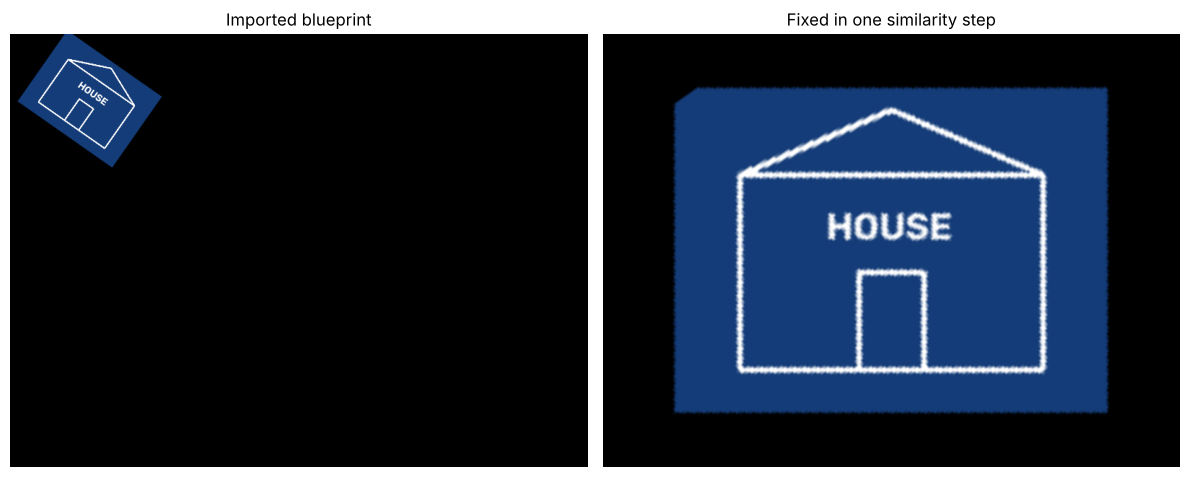

In [10]:
bp = np.full((300, 400, 3), (120, 60, 20), np.uint8)             # blueprint blue (BGR)
cv2.rectangle(bp, (60, 80), (340, 260), (255, 255, 255), 3); cv2.line(bp, (60, 80), (200, 20), (255, 255, 255), 3); cv2.line(bp, (200, 20), (340, 80), (255, 255, 255), 3)
cv2.rectangle(bp, (170, 170), (230, 260), (255, 255, 255), 3); cv2.putText(bp, 'HOUSE', (140, 140), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)
canvas = (800, 600)
bpc = np.array([200, 150])
M_messy = T(110, 90) @ R(35) @ S(0.4) @ T(*-bpc)                 # small, rotated, in the corner
messy = warp(bp, M_messy, canvas)

M_sim = T(400, 300) @ R(0) @ S(1.5) @ T(*-bpc)                   # desired final placement
M_fix = M_sim @ np.linalg.inv(M_messy)                           # one matrix applied to the messy import
A = M_fix[:2, :2]
print('Similarity 3x3:\n', M_fix.round(3))
print('scale factor =', np.sqrt(np.linalg.det(A)).round(3), '| rotation =', np.degrees(np.arctan2(A[1, 0], A[0, 0])).round(1), '°  (angles preserved, size changed)')
show([messy, warp(messy, M_fix, canvas)], ['Imported blueprint', 'Fixed in one similarity step'], size=6)

## Task 7 — The Glitched Image (General Affine from 3 points)
6 unknowns (a, b, tx, c, d, ty), each point pair gives 2 equations ⇒ **3 points**:
x = a·x' + b·y' + tx,  y = c·x' + d·y' + ty  → solve **A·m = b** with `np.linalg.solve`.

landmarks glitched: [[175.0, 145.0], [422.0, 114.0], [407.0, 346.5]]
solved affine:
 [[   1.1429   -0.5714  -17.1429]
 [   0.2449    1.3061 -132.2449]]
same as cv2.getAffineTransform: True


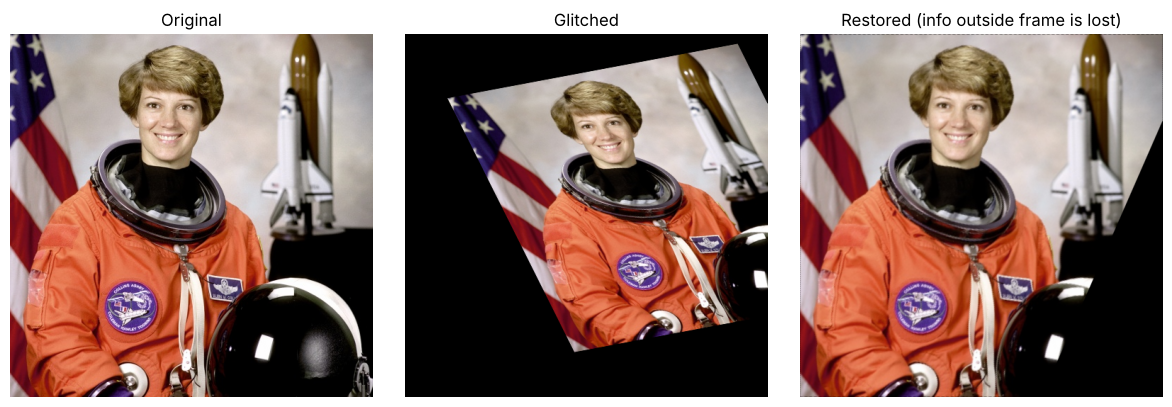

In [11]:
img = cv2.imread('data/image.jpg'); h, w = img.shape[:2]
M_glitch = np.float32([[0.8, 0.35, 60], [-0.15, 0.7, 90]])       # squish + slant + rotate + move
glitched = cv2.warpAffine(img, M_glitch, (w, h))

orig_pts = np.float32([[100, 100], [400, 120], [250, 420]])      # 3 landmarks in the correct photo
glitch_pts = cv2.transform(orig_pts[None], M_glitch)[0]          # where they ended up
print('landmarks glitched:', glitch_pts.round(1).tolist())

# Build the 6x6 linear system: maps glitched -> original
Amat, bvec = [], []
for (xg, yg), (xo, yo) in zip(glitch_pts, orig_pts):
    Amat.append([xg, yg, 1, 0, 0, 0]); bvec.append(xo)
    Amat.append([0, 0, 0, xg, yg, 1]); bvec.append(yo)
m = np.linalg.solve(np.array(Amat, float), np.array(bvec, float))
M_fix = m.reshape(2, 3)
print('solved affine:\n', M_fix.round(4))
print('same as cv2.getAffineTransform:', np.allclose(M_fix, cv2.getAffineTransform(glitch_pts, orig_pts), atol=1e-3))
restored = cv2.warpAffine(glitched, M_fix.astype(np.float32), (w, h))
show([img, glitched, restored], ['Original', 'Glitched', 'Restored (info outside frame is lost)'])

# E. Tasks 8–10 (Projective)
Homography **H (3×3, 8 unknowns)** ⇒ needs **4 point pairs**. x' = (h11x+h12y+h13)/(h31x+h32y+h33) — the changing denominator creates perspective. Affine bottom row is [0 0 1] (denominator = 1).
## Task 8 — The Sidewalk Illusion (bird's-eye view)

H (manual) =
 [[ 6.9705000e+00  3.6054000e+00 -1.8916446e+03]
 [-0.0000000e+00  1.0575900e+01 -8.4607230e+02]
 [-0.0000000e+00  1.8100000e-02  1.0000000e+00]] 
matches OpenCV: True


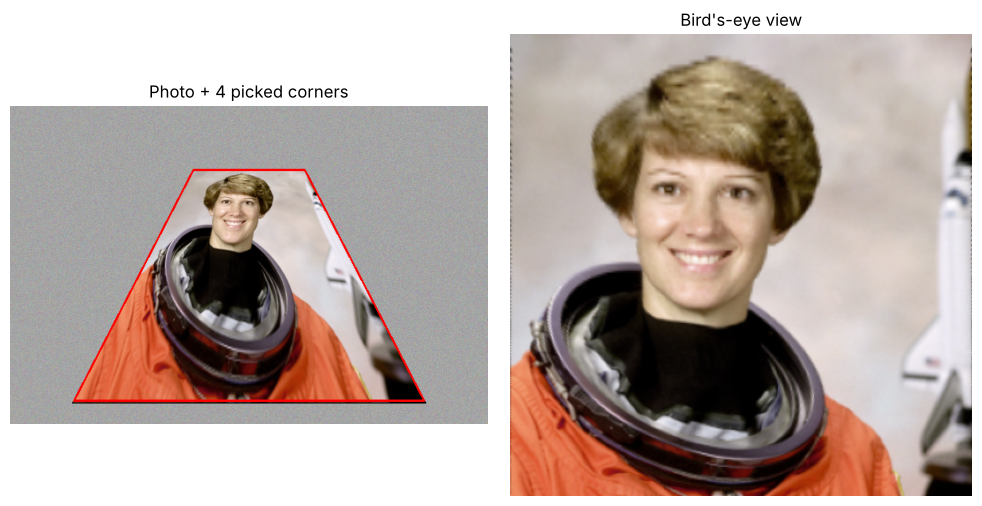

In [12]:
art = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR)[0:300, 100:400]       # the chalk art (square)
side = np.full((400, 600, 3), 150, np.uint8)
side = cv2.add(side, np.random.default_rng(0).integers(0, 30, side.shape, dtype=np.uint8))
trap = np.float32([[230, 80], [370, 80], [520, 370], [80, 370]])   # far edge (top) looks smaller
Hc = cv2.getPerspectiveTransform(np.float32([[0, 0], [299, 0], [299, 299], [0, 299]]), trap)
mask = cv2.warpPerspective(np.full((300, 300), 255, np.uint8), Hc, (600, 400))
photo = side.copy(); photo[mask > 0] = cv2.warpPerspective(art, Hc, (600, 400))[mask > 0]

# --- the task: 4 corners of the art -> perfect square ---
corners = trap                                                   # picked on the photo (TL, TR, BR, BL)
square = np.float32([[0, 0], [399, 0], [399, 399], [0, 399]])

def homography_dlt(src, dst):                                    # build H by hand (8 equations, h33 = 1)
    A, b = [], []
    for (x, y), (u, v) in zip(src, dst):
        A.append([x, y, 1, 0, 0, 0, -u * x, -u * y]); b.append(u)
        A.append([0, 0, 0, x, y, 1, -v * x, -v * y]); b.append(v)
    hvec = np.linalg.solve(np.array(A, float), np.array(b, float))
    return np.append(hvec, 1).reshape(3, 3)

H_manual = homography_dlt(corners, square)
H_cv = cv2.getPerspectiveTransform(corners, square)
print('H (manual) =\n', H_manual.round(4), '\nmatches OpenCV:', np.allclose(H_manual, H_cv, atol=1e-6))
birdseye = cv2.warpPerspective(photo, H_cv, (400, 400))
marked = photo.copy(); cv2.polylines(marked, [corners.astype(np.int32)], True, (0, 0, 255), 2)
show([marked, birdseye], ['Photo + 4 picked corners', "Bird's-eye view"], size=5)

## Task 9 — The Stadium Panorama (Homography stitching with 4 points)

Homography cam2 -> cam1:
 [[ 9.4910e-01 -3.8000e-02  2.6000e+02]
 [-3.0000e-02  1.0012e+00 -0.0000e+00]
 [-2.0000e-04  0.0000e+00  1.0000e+00]]


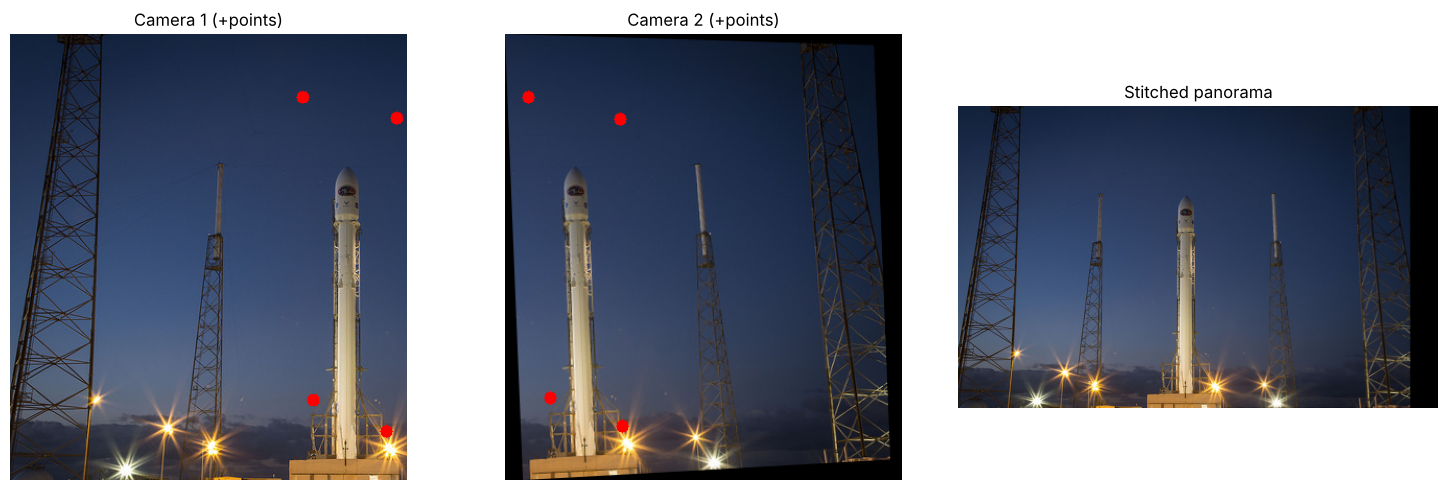

In [13]:
scene = cv2.cvtColor(data.rocket(), cv2.COLOR_RGB2BGR)            # 427 x 640 'stadium'
h, w = scene.shape[:2]
cam1 = scene[:, :380].copy()                                       # left camera
cam2_flat = scene[:, 260:].copy()                                  # right camera (overlap x=260..380)
Hcam = np.array([[1.0, 0.04, 0], [0.03, 1.0, 0], [0.0002, 0, 1]])  # 2nd camera at a slightly different angle
cam2 = cv2.warpPerspective(cam2_flat, Hcam, (cam2_flat.shape[1], h))

# 4 matching points inside the overlap (would be picked by eye / SIFT)
p1 = np.float32([[280, 60], [370, 80], [360, 380], [290, 350]])            # in cam1
p2 = cv2.perspectiveTransform((p1 - [260, 0]).reshape(-1, 1, 2), Hcam).reshape(-1, 2).astype(np.float32)  # same points in cam2

H = cv2.getPerspectiveTransform(p2, p1)                          # project cam2 into cam1's space
pano = cv2.warpPerspective(cam2, H, (w + 40, h))                 # wide canvas
pano[:, :380] = cam1                                             # paste first camera on top
print('Homography cam2 -> cam1:\n', H.round(4))
c1 = cam1.copy(); c2 = cam2.copy()
for (a, b) in zip(p1, p2): cv2.circle(c1, tuple(map(int, a)), 6, (0, 0, 255), -1); cv2.circle(c2, tuple(map(int, b)), 6, (0, 0, 255), -1)
show([c1, c2, pano], ['Camera 1 (+points)', 'Camera 2 (+points)', 'Stitched panorama'], size=5)

## Task 10 — The Master Forger (Linear Scale → Rigid → Projective)

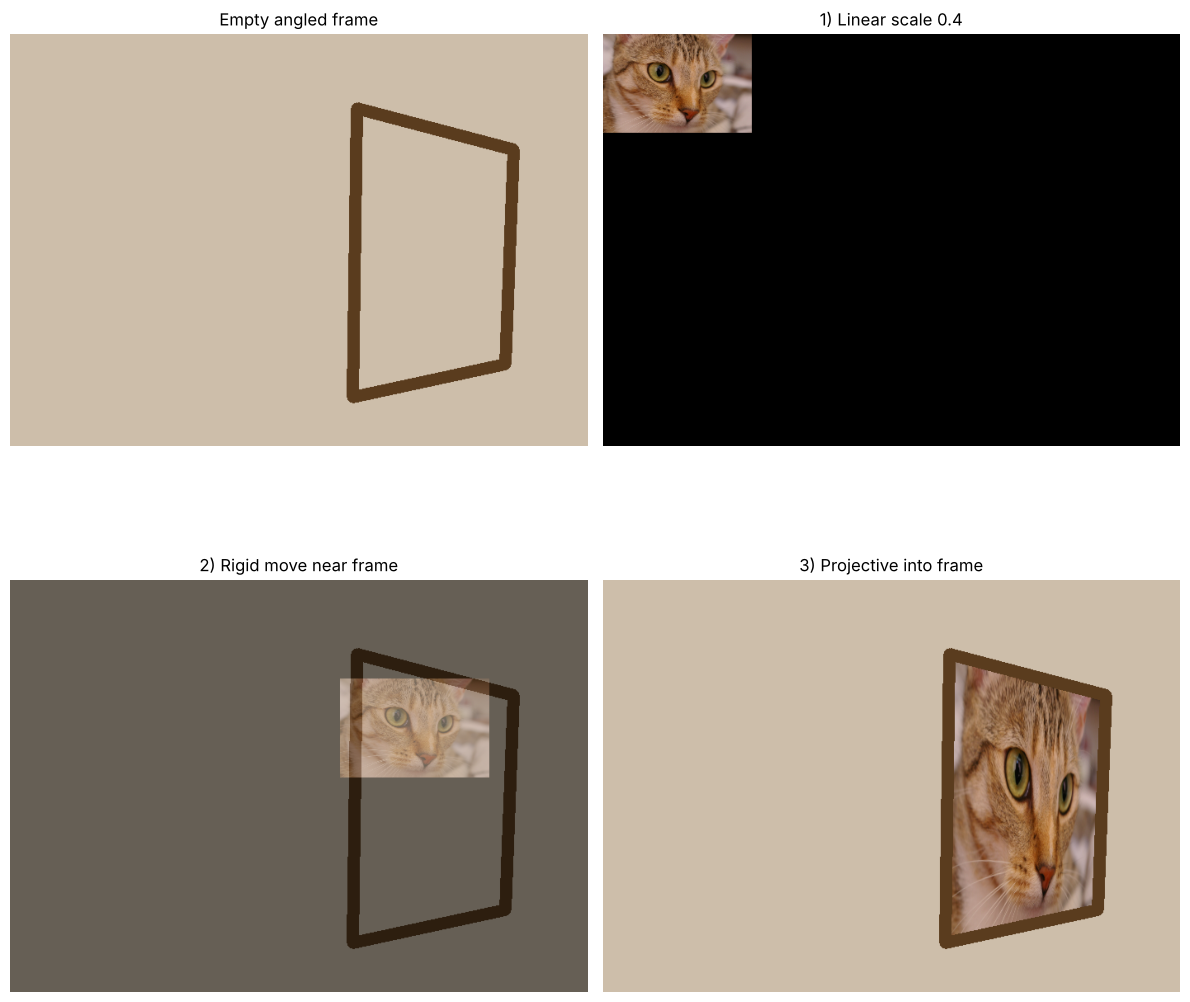

In [14]:
painting = cv2.cvtColor(data.chelsea(), cv2.COLOR_RGB2BGR)       # 300 x 451 flat painting
wall = np.full((500, 700, 3), (170, 190, 205), np.uint8)
frame_q = np.int32([[420, 90], [610, 140], [600, 400], [415, 440]])      # angled empty frame (inner corners)
cv2.polylines(wall, [frame_q], True, (30, 60, 90), 14)

ph, pw = painting.shape[:2]
corners = np.float32([[0, 0], [pw - 1, 0], [pw - 1, ph - 1], [0, ph - 1]])

# Step 1 - Linear scale (shrink to ~40%)
M1 = S(0.4)
# Step 2 - Rigid (rotation 0, translation) to move it near the frame
M2 = T(400, 120) @ R(0)
step12 = M2 @ M1
moved = warp(painting, step12, (700, 500))
moved_corners = cv2.perspectiveTransform(corners.reshape(-1, 1, 2), step12).reshape(-1, 2).astype(np.float32)

# Step 3 - Projective: moved painting corners -> frame corners
Hp = cv2.getPerspectiveTransform(moved_corners, frame_q.astype(np.float32))
final_M = Hp @ step12                                            # full chain in one 3x3
warped = cv2.warpPerspective(painting, final_M, (700, 500))
mask = cv2.warpPerspective(np.full((ph, pw), 255, np.uint8), final_M, (700, 500))
forged = wall.copy(); forged[mask > 0] = warped[mask > 0]
cv2.polylines(forged, [frame_q], True, (30, 60, 90), 14)
step1 = warp(painting, M1, (700, 500))
show([wall, step1, cv2.addWeighted(wall, .5, moved, .5, 0), forged],
     ['Empty angled frame', '1) Linear scale 0.4', '2) Rigid move near frame', '3) Projective into frame'], cols=2, size=6)